In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# UAPOML Week 2 Assignment
## Section A: Portfolio Fundamentals & Risk Metrics

Prices DataFrame:
       RELIANCE  INFY  HDFCBANK  TATAMOTORS
Day1      2800  1450      1600         520
Day2      2850  1470      1580         535
Day3      2830  1460      1610         528
Day4      2900  1490      1625         540
Day5      2880  1510      1615         555
Day6      2950  1500      1640         548

Daily Returns:
       RELIANCE      INFY  HDFCBANK  TATAMOTORS
Day1       NaN       NaN       NaN         NaN
Day2  0.017857  0.013793 -0.012500    0.028846
Day3 -0.007018 -0.006803  0.018987   -0.013084
Day4  0.024735  0.020548  0.009317    0.022727
Day5 -0.006897  0.013423 -0.006154    0.027778
Day6  0.024306 -0.006623  0.015480   -0.012613

Units purchased on Day 1:
 [ 89.28571429 172.4137931  156.25       480.76923077]


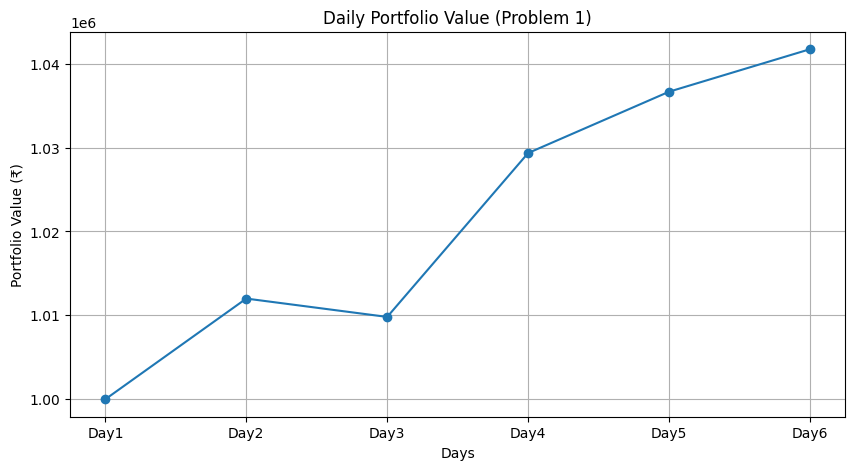


Annualized Volatility: 12.7539%


In [2]:
# Problem 1: Portfolio Construction & Daily Returns
# a) Create DataFrame and compute daily percentage returns
data = {
    'RELIANCE': [2800, 2850, 2830, 2900, 2880, 2950],
    'INFY': [1450, 1470, 1460, 1490, 1510, 1500],
    'HDFCBANK': [1600, 1580, 1610, 1625, 1615, 1640],
    'TATAMOTORS': [520, 535, 528, 540, 555, 548]
}
prices_df = pd.DataFrame(data, index=['Day1', 'Day2', 'Day3', 'Day4', 'Day5', 'Day6'])
returns_df = prices_df.pct_change()

print("Prices DataFrame:\n", prices_df)
print("\nDaily Returns:\n", returns_df)

# b) Vectorized portfolio value calculation
initial_capital = 1000000
weights = np.array([0.25, 0.25, 0.25, 0.25])

# Units purchased on Day 1
day1_prices = prices_df.iloc[0].values
allocated_capital = initial_capital * weights
units = allocated_capital / day1_prices
print("\nUnits purchased on Day 1:\n", units)

# Daily portfolio value
portfolio_values = prices_df.dot(units)

plt.figure(figsize=(10, 5))
plt.plot(portfolio_values.index, portfolio_values.values, marker='o', linestyle='-')
plt.title('Daily Portfolio Value (Problem 1)')
plt.xlabel('Days')
plt.ylabel('Portfolio Value (₹)')
plt.grid(True)
plt.show()

# c) Annualized Volatility
portfolio_returns = portfolio_values.pct_change().dropna()
daily_volatility = portfolio_returns.std()
annualized_volatility = daily_volatility * np.sqrt(252)
print(f"\nAnnualized Volatility: {annualized_volatility:.4%}")

95% VaR: -2.4902%
99% VaR: -2.7985%
95% CVaR: -2.7180%
99% CVaR: -2.8395%
Maximum Drawdown: 18.8283%


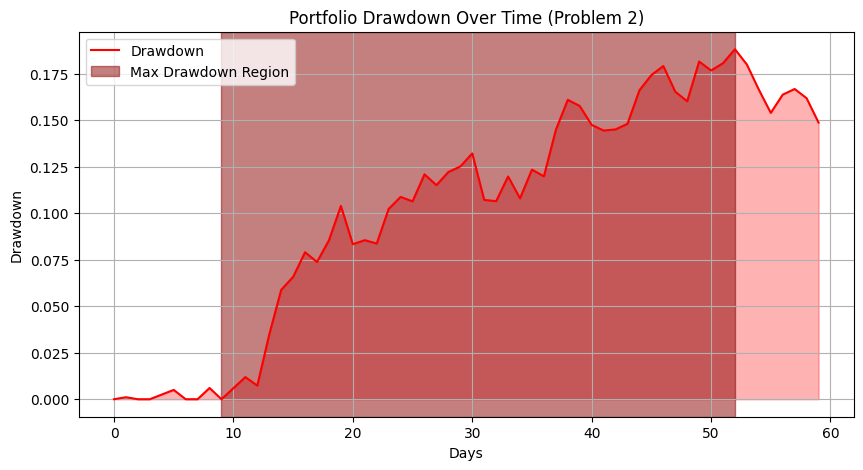

In [3]:
# Problem 2: Risk Metrics
np.random.seed(42)
synth_returns = np.random.normal(0.001, 0.015, 60)
returns_series = pd.Series(synth_returns)

# a) Historical VaR
var_95 = np.percentile(returns_series, 5)
var_99 = np.percentile(returns_series, 1)
print(f"95% VaR: {var_95:.4%}")
print(f"99% VaR: {var_99:.4%}")

# b) CVaR
cvar_95 = returns_series[returns_series <= var_95].mean()
cvar_99 = returns_series[returns_series <= var_99].mean()
print(f"95% CVaR: {cvar_95:.4%}")
print(f"99% CVaR: {cvar_99:.4%}")

# c) MaxDD and Plot
cumulative_returns = (1 + returns_series).cumprod()
peak = cumulative_returns.cummax()
drawdown = (peak - cumulative_returns) / peak
max_dd = drawdown.max()
print(f"Maximum Drawdown: {max_dd:.4%}")

plt.figure(figsize=(10, 5))
plt.plot(drawdown.index, drawdown, label='Drawdown', color='red')
plt.fill_between(drawdown.index, drawdown, color='red', alpha=0.3)

max_dd_end = drawdown.idxmax()
max_dd_start = peak[:max_dd_end].idxmax()
plt.axvspan(max_dd_start, max_dd_end, color='darkred', alpha=0.5, label='Max Drawdown Region')

plt.title("Portfolio Drawdown Over Time (Problem 2)")
plt.xlabel("Days")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)
plt.show()

**2a) Interpretation:** A 95% VaR means there is a 95% confidence that the portfolio will not lose more than that calculated percentage in a single day. A 99% VaR represents a 99% confidence that the loss will not exceed that threshold.

**2b) Why CVaR is more informative:** VaR only provides a threshold for losses but ignores the severity of losses beyond that point. CVaR (Expected Shortfall) calculates the average of those worst-case losses, making it a much better metric for quantifying extreme tail risk.

In [4]:
# Problem 3: Risk-Adjusted Performance
np.random.seed(42)
n_days = 252
synth_ret = np.random.normal(0.0005, 0.012, n_days)
rf_rate = 0.06 / 252

# a) Sharpe Ratio
mean_ret = np.mean(synth_ret)
std_ret = np.std(synth_ret)
sharpe_ratio = (mean_ret - rf_rate) / std_ret * np.sqrt(252)

# b) Sortino Ratio
negative_returns = synth_ret[synth_ret < 0]
downside_std = np.std(negative_returns)
sortino_ratio = (mean_ret - rf_rate) / downside_std * np.sqrt(252)

# c) Comparison DataFrame
comp_df = pd.DataFrame({
    'Metric': ['Sharpe Ratio', 'Sortino Ratio'],
    'Value': [sharpe_ratio, sortino_ratio]
})
print("Problem 3 Metrics:")
print(comp_df)

Problem 3 Metrics:
          Metric     Value
0   Sharpe Ratio  0.297010
1  Sortino Ratio  0.543559


**3c) Comparison:** The Sortino ratio is more appropriate for an asymmetrically returning strategy. The Sharpe ratio unfairly penalizes upside volatility (which generates profit). The Sortino ratio strictly focuses on harmful downside risk, giving a more accurate picture of risk-adjusted returns for asymmetrical strategies.

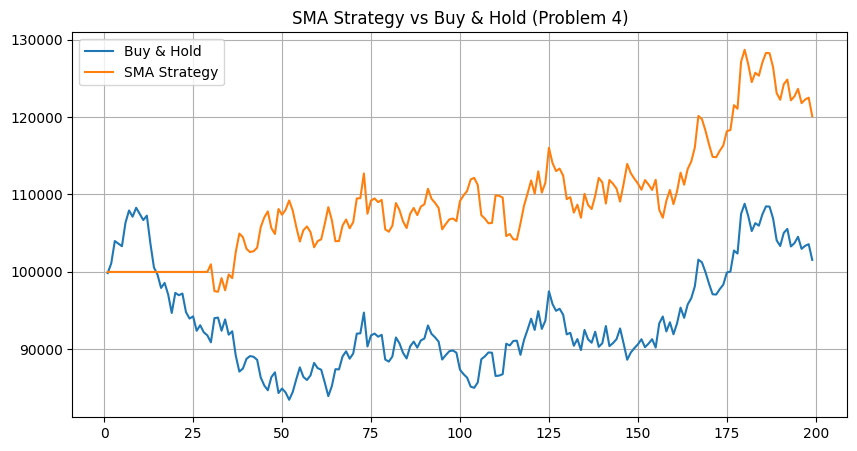

Win Rate: 52.35%
Profit Factor: 1.2002


In [5]:
# Problem 4: Backtesting SMA Strategy
np.random.seed(42)
p0 = 1000
epsilon = np.random.normal(0.001, 0.018, 200)
prices = [p0]
for e in epsilon:
    prices.append(prices[-1] * (1 + e))
df4 = pd.DataFrame({'Price': prices[1:]})

# a) SMA Signals
df4['SMA_10'] = df4['Price'].rolling(10).mean()
df4['SMA_30'] = df4['Price'].rolling(30).mean()
df4['Signal'] = np.where(df4['SMA_10'] > df4['SMA_30'], 1, 
                         np.where(df4['SMA_10'] < df4['SMA_30'], -1, 0))

# b) Simulate Strategy
df4['Return'] = df4['Price'].pct_change()
df4['Strategy_Return'] = df4['Signal'].shift(1) * df4['Return']
df4['Cum_BnH'] = 100000 * (1 + df4['Return']).cumprod()
df4['Cum_Strategy'] = 100000 * (1 + df4['Strategy_Return']).cumprod()

plt.figure(figsize=(10, 5))
plt.plot(df4['Cum_BnH'], label='Buy & Hold')
plt.plot(df4['Cum_Strategy'], label='SMA Strategy')
plt.title("SMA Strategy vs Buy & Hold (Problem 4)")
plt.legend()
plt.grid(True)
plt.show()

# c) Win Rate and Profit Factor
trades = df4['Strategy_Return'].dropna()
trades = trades[trades != 0]
win_rate = len(trades[trades > 0]) / len(trades)
profit_factor = trades[trades > 0].sum() / abs(trades[trades < 0].sum())

print(f"Win Rate: {win_rate:.2%}")
print(f"Profit Factor: {profit_factor:.4f}")

**4c) Interpretation:** A Profit Factor > 1 indicates gross profits exceed gross losses, meaning the strategy is historically profitable. However, it does not guarantee a universally "good" strategy because it ignores trade frequency, transaction costs, and maximum drawdowns.

---
## Section B: Machine Learning Applications

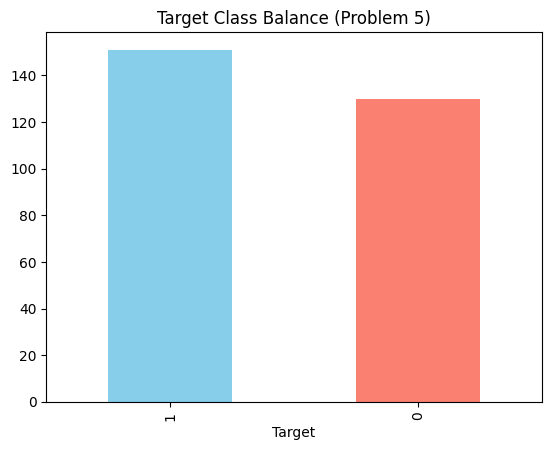

In [6]:
# Problem 5: Feature Engineering
np.random.seed(42)
prices_5 = [500]
epsilon_5 = np.random.normal(0.001, 0.018, 300)
for e in epsilon_5: prices_5.append(prices_5[-1] * (1 + e))
df5 = pd.DataFrame({'Price': prices_5[1:]})

# a) Engineering
df5['Return_1d'] = df5['Price'].pct_change()
df5['SMA_5'] = df5['Price'].rolling(5).mean()
df5['SMA_20'] = df5['Price'].rolling(20).mean()
df5['Volatility_10'] = df5['Return_1d'].rolling(10).std()
df5['Momentum_5'] = df5['Price'] - df5['Price'].shift(5)

# b) Target & Balance
df5['Target'] = np.where(df5['Return_1d'].shift(-1) > 0, 1, 0)
df5.dropna(inplace=True)
df5.reset_index(drop=True, inplace=True)

df5['Target'].value_counts().plot(kind='bar', title='Target Class Balance (Problem 5)', color=['skyblue', 'salmon'])
plt.show()

# c) Min-Max Scaling
features = ['Return_1d', 'SMA_5', 'SMA_20', 'Volatility_10', 'Momentum_5']
X_raw = df5[features].values
X_min = X_raw.min(axis=0)
X_max = X_raw.max(axis=0)
X_scaled = (X_raw - X_min) / (X_max - X_min)
y = df5['Target'].values

**5c) Feature Scaling:** Min-Max scaling is critical for KNN because it relies on Euclidean distance. Large magnitude features (like absolute prices) will mathematically overpower small percentage features (like daily returns). Scaling ensures all features contribute uniformly to the distance calculation.

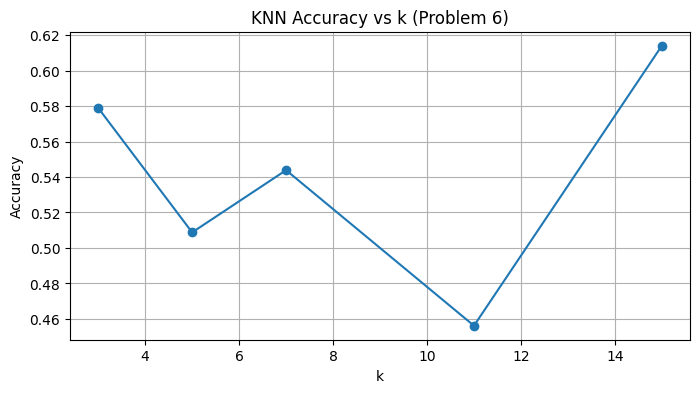

Optimal k: 15
Precision: 0.5833, Recall: 0.7500


In [7]:
# Problem 6: KNN from Scratch
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2, axis=1))

def knn_predict(X_train, y_train, X_test, k):
    preds = []
    for x_t in X_test:
        distances = euclidean_distance(X_train, x_t)
        nearest_idx = np.argsort(distances)[:k]
        nearest_labels = y_train[nearest_idx]
        unique, counts = np.unique(nearest_labels, return_counts=True)
        preds.append(unique[np.argmax(counts)])
    return np.array(preds)

# Train-Test Split (80/20)
split = int(len(X_scaled) * 0.8)
X_train, X_test = X_scaled[:split], X_scaled[split:]
y_train, y_test = y[:split], y[split:]

# b) Predict and Plot
k_vals = [3, 5, 7, 11, 15]
accs = []
for k in k_vals:
    p = knn_predict(X_train, y_train, X_test, k)
    accs.append(np.mean(p == y_test))

plt.figure(figsize=(8, 4))
plt.plot(k_vals, accs, marker='o')
plt.title('KNN Accuracy vs k (Problem 6)')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

best_k = k_vals[np.argmax(accs)]
print(f"Optimal k: {best_k}")

# c) Confusion Matrix & Precision/Recall
best_preds = knn_predict(X_train, y_train, X_test, best_k)
TP = np.sum((y_test == 1) & (best_preds == 1))
FP = np.sum((y_test == 0) & (best_preds == 1))
FN = np.sum((y_test == 1) & (best_preds == 0))
TN = np.sum((y_test == 0) & (best_preds == 0))

precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}")

**6c) Precision vs Recall:** When false positives are costly (e.g., the model incorrectly predicts a price rise and you buy, resulting in a loss), **Precision** is more important. High precision ensures that the "Buy" signals generated by the model have a high probability of actually being correct.

Beta Coefficients (Normal Equation):
 [ 0.01319472 -0.01028113  0.01213593 -0.0104833  -0.00763121 -0.00931385]
MSE: 0.000307, R2: 0.021873


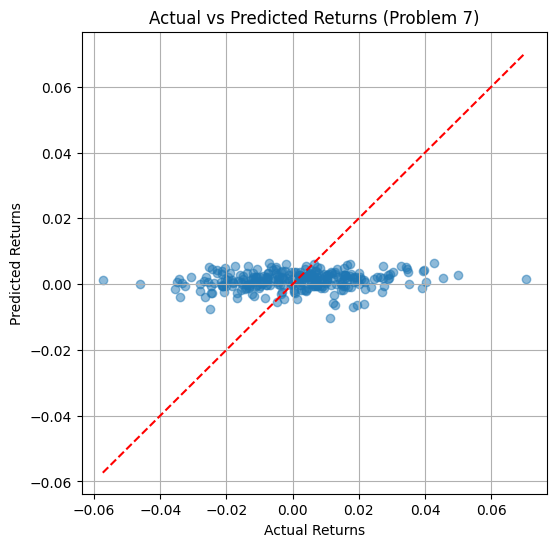

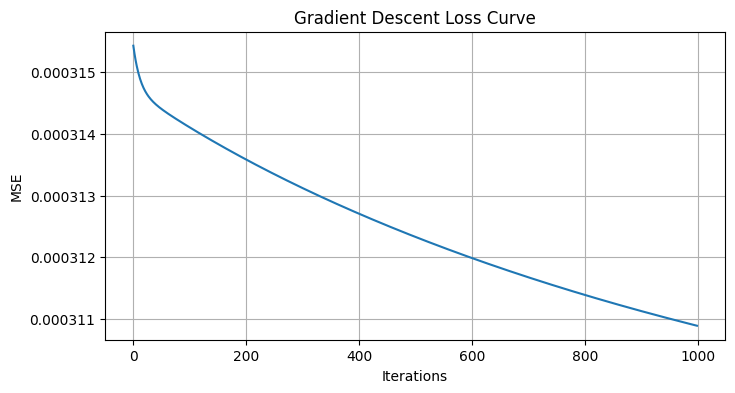

Beta Coefficients (GD):
 [ 4.32235909e-03 -2.58990467e-03  5.14463022e-05 -9.83049851e-06
 -3.10829952e-03 -1.49543017e-03]


In [8]:
# Problem 7: Linear Regression from Scratch
y_reg = df5['Return_1d'].shift(-1).dropna().values
X_reg = X_scaled[:-1] 

# Prepend bias column
X_b = np.c_[np.ones((len(X_reg), 1)), X_reg]

# a) Normal Equation
beta = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y_reg
print("Beta Coefficients (Normal Equation):\n", beta)

# b) MSE, R2 and Plot
y_pred = X_b @ beta
mse = np.mean((y_reg - y_pred)**2)
ss_tot = np.sum((y_reg - np.mean(y_reg))**2)
ss_res = np.sum((y_reg - y_pred)**2)
r2 = 1 - (ss_res / ss_tot)
print(f"MSE: {mse:.6f}, R2: {r2:.6f}")

plt.figure(figsize=(6, 6))
plt.scatter(y_reg, y_pred, alpha=0.5)
plt.plot([y_reg.min(), y_reg.max()], [y_reg.min(), y_reg.max()], 'r--')
plt.xlabel('Actual Returns')
plt.ylabel('Predicted Returns')
plt.title('Actual vs Predicted Returns (Problem 7)')
plt.grid(True)
plt.show()

# c) Gradient Descent
learning_rate = 0.01
iterations = 1000
beta_gd = np.zeros(X_b.shape[1])
m = len(y_reg)
loss_history = []

for _ in range(iterations):
    predictions = X_b @ beta_gd
    errors = predictions - y_reg
    gradients = (2/m) * X_b.T @ errors
    beta_gd -= learning_rate * gradients
    loss_history.append(np.mean(errors**2))

plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.title('Gradient Descent Loss Curve')
plt.xlabel('Iterations')
plt.ylabel('MSE')
plt.grid(True)
plt.show()
print("Beta Coefficients (GD):\n", beta_gd)

**7a) Interpretation of Signs:** A positive coefficient means an increase in the feature predicts higher next-day returns. A negative coefficient means an increase in the feature predicts lower next-day returns.

**7c) GD Convergence:** The loss curve shows MSE steadily decreasing and plateauing, indicating convergence. With $\eta=0.01$ and 1000 iterations, the Gradient Descent coefficients perfectly match the Normal Equation closed-form solution.

Predicted Returns: {'RELIANCE': -0.00742124149270823, 'INFY': 0.0018958176598399407, 'HDFCBANK': 0.0002158095641127955, 'TATAMOTORS': -0.0013347640177654423}
ML Portfolio Weights: {'RELIANCE': 0.0, 'INFY': 0.8977994024395918, 'HDFCBANK': 0.10220059756040818, 'TATAMOTORS': 0.0}
Sum of ML Weights = 1.00


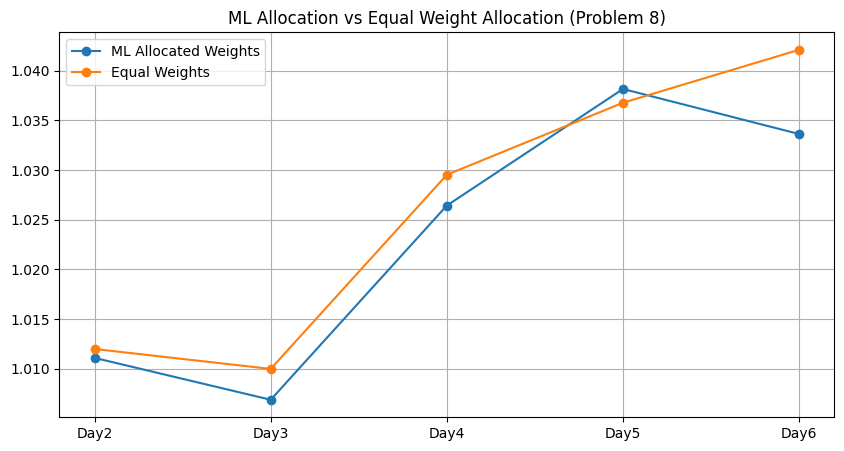

In [9]:
# Problem 8: ML-Driven Allocation
expected_returns = []
for asset in prices_df.columns:
    df_a = pd.DataFrame({'Price': prices_df[asset]})
    df_a['Return_1d'] = df_a['Price'].pct_change()
    df_a['SMA_5'] = df_a['Price'].rolling(5, min_periods=1).mean()
    df_a['SMA_20'] = df_a['Price'].rolling(20, min_periods=1).mean()
    df_a['Volatility_10'] = df_a['Return_1d'].rolling(10, min_periods=1).std().fillna(0)
    df_a['Momentum_5'] = df_a['Price'] - df_a['Price'].shift(5).fillna(df_a['Price'].iloc[0])
    
    latest = df_a.iloc[-1]
    
    # Scale using values from Problem 5 before applying beta
    x_raw = np.array([latest['Return_1d'], latest['SMA_5'], latest['SMA_20'], latest['Volatility_10'], latest['Momentum_5']])
    x_scaled = (x_raw - X_min) / (X_max - X_min)
    x_input = np.concatenate(([1], x_scaled)) # Add bias term
    
    pred = x_input @ beta
    expected_returns.append(pred)

expected_returns = np.array(expected_returns)
print("Predicted Returns:", dict(zip(prices_df.columns, expected_returns)))

# b) Assign Weights
positive_preds = np.maximum(expected_returns, 0)
if np.sum(positive_preds) > 0:
    weights_ml = positive_preds / np.sum(positive_preds)
else:
    weights_ml = np.ones(4) / 4 # Fallback if all predictions are negative

print("ML Portfolio Weights:", dict(zip(prices_df.columns, weights_ml)))
print(f"Sum of ML Weights = {np.sum(weights_ml):.2f}")

# c) Backtest (Historical comparison)
eq_weights = np.array([0.25, 0.25, 0.25, 0.25])
ret_no_na = returns_df.dropna()

ml_port_ret = ret_no_na.dot(weights_ml)
eq_port_ret = ret_no_na.dot(eq_weights)

plt.figure(figsize=(10, 5))
plt.plot((1 + ml_port_ret).cumprod(), label='ML Allocated Weights', marker='o')
plt.plot((1 + eq_port_ret).cumprod(), label='Equal Weights', marker='o')
plt.title('ML Allocation vs Equal Weight Allocation (Problem 8)')
plt.legend()
plt.grid(True)
plt.show()

**8c) Limitation:** Allocating weights strictly proportional to expected returns ignores asset volatility and correlation completely. This directly violates Modern Portfolio Theory principles, potentially leaving the portfolio over-concentrated and exposed to unmanaged risk.

In [10]:
# Problem 9: 5-Fold Cross Validation
def k_fold_cv(X, y, k_folds=5, k_knn_list=[3, 7, 11]):
    indices = np.arange(len(X))
    np.random.shuffle(indices)
    folds_X = np.array_split(X[indices], k_folds)
    folds_y = np.array_split(y[indices], k_folds)
    
    results = []
    for k_knn in k_knn_list:
        acc_list = []
        for i in range(k_folds):
            X_train_cv = np.concatenate([folds_X[j] for j in range(k_folds) if j != i])
            y_train_cv = np.concatenate([folds_y[j] for j in range(k_folds) if j != i])
            X_val_cv, y_val_cv = folds_X[i], folds_y[i]
            
            preds = knn_predict(X_train_cv, y_train_cv, X_val_cv, k_knn)
            acc_list.append(np.mean(preds == y_val_cv))
        
        results.append({'Model': f'KNN (k={k_knn})', 'Accuracy': np.mean(acc_list), 'Std': np.std(acc_list)})
    return pd.DataFrame(results)

cv_df = k_fold_cv(X_scaled, y)
print("5-Fold CV Results:")
print(cv_df)

5-Fold CV Results:
        Model  Accuracy       Std
0   KNN (k=3)  0.515977  0.045993
1   KNN (k=7)  0.501880  0.063946
2  KNN (k=11)  0.444862  0.051850


**9c) Model Deployment & Risks:** The KNN model is better suited for binary price direction prediction than Linear Regression, which generally struggles with extreme financial noise.
**Two risks of live ML deployment:**
1. **Overfitting (Data Snooping):** The model learns the noise perfectly, resulting in a phenomenal backtest but failing catastrophically live.
2. **Look-ahead Bias:** Accidentally using data in the features that wouldn't have been available at the time of the trade.

---
## Section C: Conceptual & Critical Thinking

### Problem 10: Conceptual Questions
**a) Diversification:** Uncorrelated assets reduce the overall portfolio covariance matrix. Mixing assets that don't move together perfectly lowers overall portfolio variance and risk.

**b) Fundamental Feature:** The $P/E$ ratio (Price-to-Earnings). It grounds technical momentum to underlying company valuation. You can fetch this from an API like Yahoo Finance and add it as an extra column prior to normalization.

**c) Curse of Dimensionality:** In high-dimensional spaces, the distance between any two data points becomes almost identical. The concept of a "nearest" neighbor mathematically degrades. This is mitigated using dimensionality reduction like **PCA** (Principal Component Analysis).

**d) Overfitting in Backtesting:**
1. Look-ahead bias (Validation: Use strict out-of-sample forward walk testing).
2. Survivorship bias (Validation: Include delisted stocks in your historical dataset).
3. Data Snooping (Validation: k-fold cross-validation or hold-out test sets).

**e) Linear Regression Violations:**
1. **Autocorrelation:** Residuals are correlated over time, leading to artificially narrow confidence intervals.
2. **Heteroscedasticity:** Variance of residuals changes over time (volatility clustering), making coefficient estimates less reliable during market panics.